In [ ]:
!pip install transformers torchvision pillow grad-cam lime gradio -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 19.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 19.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from transformers import DistilBertTokenizer, DistilBertModel
from PIL import Image
import requests
from io import BytesIO
import numpy as np
import matplotlib.pyplot as plt
import cv2

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


In [ ]:
class ImageEmbedder(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = models.resnet50(pretrained=True)
        for param in resnet.parameters():
            param.requires_grad = False
        self.backbone = nn.Sequential(*list(resnet.children())[:-1])
        self.embedding_head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(2048, 512),
            nn.ReLU()
        )
    def forward(self, x):
        return self.embedding_head(self.backbone(x))

class TextEmbedder(nn.Module):
    def __init__(self):
        super().__init__()
        self.bert = DistilBertModel.from_pretrained('distilbert-base-uncased')
        for param in self.bert.parameters():
            param.requires_grad = False
        self.embedding_head = nn.Sequential(
            nn.Linear(768, 768),
            nn.ReLU(),
            nn.Dropout(0.1)
        )
    def forward(self, input_ids, attention_mask):
        cls = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        ).last_hidden_state[:, 0, :]
        return self.embedding_head(cls)

class FusionScorer(nn.Module):
    def __init__(self):
        super().__init__()
        self.fusion = nn.Sequential(
            nn.Linear(1280, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 1)
        )
    def forward(self, img_emb, text_emb):
        return self.fusion(torch.cat([img_emb, text_emb], dim=1))

print('Classes defined')

Classes defined


In [ ]:
from google.colab import files
files.upload()

image_embedder = ImageEmbedder().to(device)
text_embedder = TextEmbedder().to(device)
fusion_model = FusionScorer().to(device)

checkpoint = torch.load('multimodal_ad_scorer.pt', map_location=device)
image_embedder.load_state_dict(checkpoint['image_embedder'])
text_embedder.load_state_dict(checkpoint['text_embedder'])
fusion_model.load_state_dict(checkpoint['fusion_model'])

image_embedder.eval()
text_embedder.eval()
fusion_model.eval()

print('Models loaded')

Saving multimodal_ad_scorer (1).pt to multimodal_ad_scorer (1).pt


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 222MB/s]


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


FileNotFoundError: [Errno 2] No such file or directory: 'multimodal_ad_scorer.pt'

In [ ]:
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean = [0.485, 0.456, 0.406], std = [0.229, 0.224, 0.225])
])

def score_ad(image, text):
  img_tensor = transform(image).unsqueeze(0).to(device)
  with torch.no_grad():
    img_emb = image_embedder(img_tensor)

  tokens = tokenizer(
        text,
        return_tensors = 'pt',
        max_length = 128,
        padding = 'max_length',
        truncation = True
  )
  with torch.no_grad():
      text_emb = text_embedder(
          tokens['input_ids'].to(device),
          tokens['attention_mask'].to(device)
  )

  with torch.no_grad():
    log_score = fusion_model(img_emb, text_emb).item()

  score = np.expm1(log_score)
  return round(float(score), 3)

  test_img = Image.new('RGB', (224, 224), color = (255,100,50))
  test_score = score_ad(test_img, "Buy now and save 50% today")
  print(f"Test score: {test_score}")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
print(type(image_embedder))
print(hasattr(image_embedder, 'backbone'))
print(hasattr(image_embedder, 'embedding_head'))

<class '__main__.ImageEmbedder'>
True
True


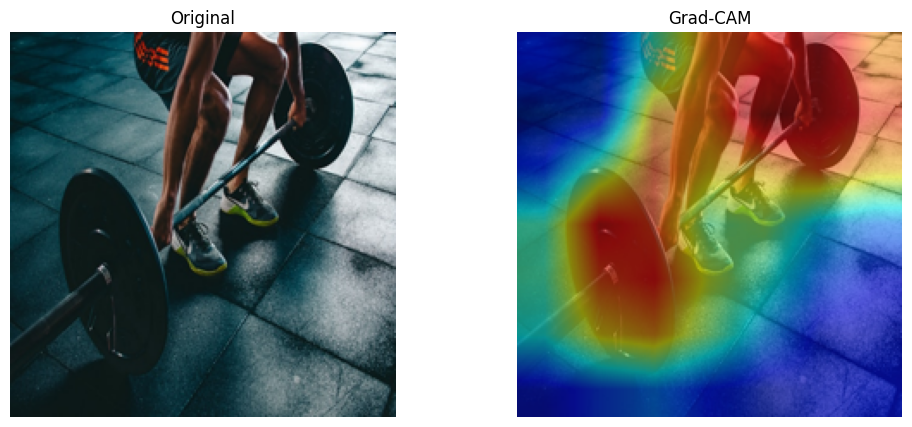

In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

target_layer = [list(image_embedder.backbone.children())[-2][-1]]

def get_gradcam(image):
    img_tensor = transform(image).unsqueeze(0).to(device)
    img_np     = np.array(image.resize((224, 224))) / 255.0

    # Temporarily enable gradients for frozen layers
    for param in image_embedder.parameters():
        param.requires_grad = True

    cam = GradCAM(model=image_embedder, target_layers=target_layer)
    grayscale_cam = cam(input_tensor=img_tensor, targets=None)[0]

    # Freeze again after CAM computation
    for param in image_embedder.parameters():
        param.requires_grad = False

    visualization = show_cam_on_image(
        img_np.astype(np.float32),
        grayscale_cam,
        use_rgb=True
    )
    return visualization

# Test
url = "https://images.unsplash.com/photo-1517836357463-d25dfeac3438?w=640"
img = Image.open(BytesIO(requests.get(url).content)).convert('RGB')
heatmap = get_gradcam(img)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img.resize((224, 224)))
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(heatmap)
axes[1].set_title('Grad-CAM')
axes[1].axis('off')
plt.show()

In [ ]:
#LIME for texts
from lime.lime_text import LimeTextExplainer

explainer = LimeTextExplainer(class_names = ['engagement_score'])

def predict_for_lime(texts):
  scores = []
  for text in texts:
    tokens = tokenizer(
        text,
        return_tensors = 'pt',
        max_length = 128,
        padding = 'max_length',
        Truncation = True
    )

    with torch.no_grad():
      dummy_img = torch.zeros(1,512).to(device)
      text_emb = text_embedder(
          tokens['input_ids'].to(device),
          tokens['attention_mask'].to(device)
      )

      score = fusion_model(dummy_img, text_emb).item()
    scores.append([0, float(np.expm1(score))])
  return np.array(scores)

def get_lime_explanation(text, num_features = 8):
  exp = explainer.explain_instance(
      text,
      predict_for_lime,
      num_features = num_features,
      num_samples = 100
  )

  return exp

test_text = "Buy now and save 50% on premium fitness gear. Limited offer ends tonight"
exp = get_lime_explanation(test_text)
exp.show_in_notebook()

In [ ]:
!pip install faiss-cpu -q #install FAISS

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 34.4 MB/s eta 0:00:00


In [ ]:
from google.colab import files
files.upload()

Saving Enriched_data_pipeline.ipynb to Enriched_data_pipeline.ipynb


{'Enriched_data_pipeline.ipynb': b'{\r\n "cells": [\r\n  {\r\n   "cell_type": "code",\r\n   "execution_count": null,\r\n   "metadata": {\r\n    "id": "VMK025Rjc_E2"\r\n   },\r\n   "outputs": [],\r\n   "source": [\r\n    "!pip install transformers torchvision pillow scikit-learn -q\\n"\r\n   ]\r\n  },\r\n  {\r\n   "cell_type": "code",\r\n   "execution_count": null,\r\n   "metadata": {\r\n    "colab": {\r\n     "base_uri": "https://localhost:8080/"\r\n    },\r\n    "id": "cdLJwIv7xnZ9",\r\n    "outputId": "1c4b894b-360e-47ac-f3aa-22b4c371c1b9"\r\n   },\r\n   "outputs": [],\r\n   "source": [\r\n    "import torch\\n",\r\n    "import torch.nn as nn\\n",\r\n    "import torchvision.models as models\\n",\r\n    "import torchvision.transforms as transforms\\n",\r\n    "from transformers import DistilBertTokenizer, DistilBertModel\\n",\r\n    "from sklearn.model_selection import train_test_split\\n",\r\n    "import numpy as np\\n",\r\n    "from PIL import Image\\n",\r\n    "import requests\\n",\

In [ ]:
#rebuilding sample
import pandas as pd
import numpy as np

ads = pd.read_csv('ads_enriched.csv')
users = pd.read_csv('users.csv')
campaigns = pd.read_csv('campaigns.csv')
events = pd.read_csv('ad_events.csv')

weights = {
    'Impression': 0,
    'Click': 1,
    'Like': 2,
    'Comment': 3,
    'Share': 4,
    'Purchase': 5
}

events['engagement_weight'] = events['event_type'].map(weights)
print(events['engagement_weight'].value_counts())

engagement = (
    events.groupby(['ad_id', 'user_id'])['engagement_weight'].sum()
    .reset_index()
    .rename(columns = {'engagement_weight': 'engagement_score'})
)

df= engagement.merge(ads, on = 'ad_id')
df = df.merge(campaigns[['campaign_id', 'total_budget', 'duration_days']], on = 'campaign_id')
df = df.merge(users[['user_id', 'user_age', 'user_gender']], on = 'user_id')
df = df[df['engagement_score']>0].copy().reset_index(drop = True)

df_sample = df.sample( n = 2000, random_state = 42).reset_index(drop = True)
print(f"Sample ready: {df_sample.shape}")

engagement_weight
0    339812
1     40079
2     12013
3      4108
5      2031
4      1957
Name: count, dtype: int64
Sample ready: (2000, 17)


In [ ]:
from transformers import DistilBertTokenizer
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
# loading tokenizer

In [ ]:
def embed_single_text(text):
    tokens = tokenizer(
        text,
        return_tensors='pt',
        max_length=128,
        padding='max_length',
        truncation=True
    )
    with torch.no_grad():
        emb = text_embedder(
            tokens['input_ids'].to(device),
            tokens['attention_mask'].to(device)
        ).cpu().numpy()
    return emb[0]  # shape (768,)

db_embeddings = np.array([
    embed_single_text(text)
    for text in high_perf_ads['ad_copy']
]).astype(np.float32)

print(f"Database embeddings shape: {db_embeddings.shape}")
# Should be (N, 768)

Database embeddings shape: (111, 768)


In [ ]:
import faiss
import numpy as np

# Build high performing ads database from real data
high_perf_ads = df_sample[df_sample['engagement_score'] >= 3][
    ['ad_copy', 'engagement_score']
].drop_duplicates(subset='ad_copy').reset_index(drop=True)

print(f"High performing ads: {high_perf_ads.shape}")  # ← fixed typo
print(high_perf_ads.head())

# Embed all database ads
print("Embedding ad database...")
db_embeddings = np.array([
    embed_single_text(text)
    for text in high_perf_ads['ad_copy']
]).astype(np.float32)

print(f"Embeddings shape: {db_embeddings.shape}")

# Build FAISS index
dimension = 768
index = faiss.IndexFlatL2(dimension)
index.add(db_embeddings)

print(f"FAISS index built with {index.ntotal} ads")

High performing ads: (111, 2)
                                             ad_copy  engagement_score
0  The Workout Plan That Actually Works Swipe thr...                 3
1  Discover Stunning Art That Speaks to You See w...                 4
2  Discover Stunning Art That Speaks to You Swipe...                 3
3  Level Up Your Gaming Experience Swipe up to di...                 3
4  Feel Better Every Single Day Limited time offe...                 5
Embedding ad database...
Embeddings shape: (111, 768)
FAISS index built with 111 ads


In [ ]:
#embedding all the database ads
def embed_single_text(text):
    tokens = tokenizer(
        text,
        return_tensors='pt',
        max_length=128,
        padding='max_length',
        truncation=True
    )
    with torch.no_grad():
        emb = text_embedder(
            tokens['input_ids'].to(device),
            tokens['attention_mask'].to(device)
        ).cpu().numpy()
    return emb[0]  # shape (768,)

db_embeddings = np.array([
    embed_single_text(text)
    for text in high_perf_ads['ad_copy']
]).astype(np.float32)

print(f"Embeddings shape: {db_embeddings.shape}")

Embeddings shape: (111, 768)


In [ ]:
#building the faiss index
dimension = 768 #distilBERT output size

index = faiss.IndexFlatL2(dimension) #calculating exact search using (L2)euclidean distance { Straight line distance bw 2 vectors}
#Used L2 distance because similar ads have smaller L2 distance, their embeddings are closer in the 768 dimension
index.add(db_embeddings)

print(f"Ads indexed: {index.ntotal}")

Ads indexed: 111


In [ ]:
#building the retrieval function
def retrieve_similar_ads(query_text, k=3):
  #takes ad copy and returns k most similar high-performing ads from database

  #embedding the query
  query_emb = embed_single_text(query_text).reshape(1, -1).astype(np.float32)

  #searching the faiss index
  distances, indices = index.search(query_emb, k)

  results = []
  for i, idx in enumerate(indices[0]):
    results.append({
        'text': high_perf_ads.iloc[idx]['ad_copy'],
        'score': high_perf_ads.iloc[idx]['engagement_score'],
        'distance': float(distances[0][1])
    })

  return results

#testing the function
similar = retrieve_similar_ads("Buy fitness gear now and save big")
print("Similar high-performing ads: ")
for ad in similar:
  print(f"Score: {ad['score']} | Distance {ad['distance']:.3f}")
  print(f"{ad['text'][:80]}")
  print()

Similar high-performing ads: 
Score: 5 | Distance 6.914
Good Food. Great Life. Click to learn more and claim your exclusive offer before

Score: 5 | Distance 6.914
Feel Better Every Single Day Watch how thousands of people are already benefitin

Score: 4 | Distance 6.914
Fresh Ingredients Delivered to Your Door Watch how thousands of people are alrea



In [ ]:
from google.colab import userdata

HF_TOKEN = userdata.get('HF_TOKEN')

In [ ]:
from huggingface_hub import login
login(HF_TOKEN)

In [ ]:
#hugging face API call
import requests as req

#Mistral-7B on HuggingFace returns the generated text when sent a prompt
def call_mistral(prompt):
  API_URL = "https://api-inference.huggingface.co/models/mistralai/Mistral-7B-Instruct-v0.1"

  headers = {'Authorization': f"Bearer {HF_TOKEN}"}

  payload = {
      "inputs": prompt,
      "parameters": {
          "max_new_tokens": 200, #max length of response
          "temperature": 0.7, #creativity - deterministic 0 : 1 creative
          "return_full_text": False
      }
  }

  response = req.post(API_URL, headers = headers, json = payload)
  result = response.json()

  if isinstance(result, list):
    return result[0]['generated_text']

  else:
    print(f"API error: {result}")
    return None

#testing the API connections
test_response = call_mistral("Write one short ad headline for a fitness product.")
print(test_response)

ConnectionError: HTTPSConnectionPool(host='api-inference.huggingface.co', port=443): Max retries exceeded with url: /models/mistralai/Mistral-7B-Instruct-v0.1 (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x7d85300d40b0>: Failed to resolve 'api-inference.huggingface.co' ([Errno -2] Name or service not known)"))

In [ ]:
#Mistral-7b API call
#But we using HuggingFace's Python client instead of raw HTTP
!pip install huggingface_hub -q

from huggingface_hub import InferenceClient

client = InferenceClient(
    model="mistralai/Mistral-7B-Instruct-v0.1",
    token=HF_TOKEN
)

def call_mistral(prompt):
    try:
        response = client.chat_completion(
            messages=[{"role": "user", "content": prompt}],
            max_tokens=200,
            temperature=0.7
        )
        return response.choices[0].message.content
    except Exception as e:
        print(f"API error: {e}")
        return None

test = call_mistral("Write one short ad headline for a fitness product.")
print(test)

API error: (Request ID: Root=1-6a282aaa-61353cb66098822c7a45f8a9;0887b791-edc2-434f-bac3-8926ad453f44)

Bad request:
{'message': "The requested model 'mistralai/Mistral-7B-Instruct-v0.1' is not supported by any provider you have enabled.", 'type': 'invalid_request_error', 'param': 'model', 'code': 'model_not_supported'}
None


In [ ]:
#Switching to Zephyr-7B
from huggingface_hub import InferenceClient

client = InferenceClient(
    model="HuggingFaceH4/zephyr-7b-beta",
    token=HF_TOKEN
)

def call_mistral(prompt):
    try:
        response = client.chat_completion(
            messages=[{"role": "user", "content": prompt}],
            max_tokens=200,
            temperature=0.7
        )
        return response.choices[0].message.content
    except Exception as e:
        print(f"API error: {e}")
        return None

test = call_mistral("Write one short ad headline for a fitness product.")
print(test)

API error: (Request ID: Root=1-6a282b0f-044ad32f64bf2da97788f12c;a1716c02-e2ca-4750-8fdf-7833251f0433)

Bad request:
{'message': "The requested model 'HuggingFaceH4/zephyr-7b-beta' is not supported by any provider you have enabled.", 'type': 'invalid_request_error', 'param': 'model', 'code': 'model_not_supported'}
None


In [3]:
#switching to API-less approach
from transformers import pipeline

# GPT-2 medium — better than OPT for creative text, still runs on Colab CPU
generator = pipeline(
    "text-generation",
    model="gpt2-medium",
    max_new_tokens=60
)

def call_llm(prompt):
    try:
        result = generator(
            prompt,
            do_sample=True,
            temperature=0.8,
            num_return_sequences=1,
            pad_token_id=50256
        )
        generated = result[0]['generated_text'].replace(prompt, '').strip()
        # Take only first line — GPT2 can ramble
        first_line = generated.split('\n')[0].strip()
        return first_line
    except Exception as e:
        print(f"Error: {e}")
        return None

test = call_llm("Write a punchy ad headline for a fitness product that motivates people to buy:")
print(test)

config.json:   0%|          | 0.00/718 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.52G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'pad_token_id', 'do_sample', 'num_return_sequences', 'temperature'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=60) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


"I'll Live to Tell The Tale: The Health & Fitness Products That Will Make You Fitter."
